In [45]:
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


In [46]:
# Load data from JSON file
with open('data.json', 'r') as f:
    json_data = json.load(f)

print("JSON data structure:")
print(f"Keys: {json_data[0].keys()}")
print(f"Number of series: {len(json_data)}")


JSON data structure:
Keys: dict_keys(['name', 'color', 'visible', 'showInLegend', 'showInNavigator', 'allowCsvDownloadForItem', 'yAxis', 'data', 'xAxisValues', 'format', 'xAxisFormat', 'timeZone', 'y0AxisDecimalPlaces', 'showNavigator', 'datasource', 'date', 'stacking', 'xAxisLabel', 'y0AxisLabel', 'y1AxisLabel', 'y1AxisDecimalPlaces', 'y2AxisLabel', 'y2AxisDecimalPlaces', 'chartTitle'])
Number of series: 19


In [47]:
# List all series names to help identify the correct one
print("Available series in JSON:")
print(f"Total series: {len(json_data)}")
for i, series in enumerate(json_data):
    try:
        if 'name' in series:
            # Handle the name structure (list of dicts)
            name_obj = series['name']
            if isinstance(name_obj, list) and len(name_obj) > 0:
                series_name_en = name_obj[0].get('en', 'Unknown')
            else:
                series_name_en = str(name_obj)
            print(f"  Series {i}: {series_name_en}")
    except Exception as e:
        print(f"  Series {i}: Error reading name - {e}")


Available series in JSON:
Total series: 19
  Series 0: {'en': 'Hydro pumped storage consumption', 'de': 'Pumpspeicher Verbrauch', 'fr': 'Hydraulique STEP consommation', 'it': 'Idroelettrico ad accumulazione con pompaggio consumo', 'es': 'Consumo de almacenamiento por bombeo'}
  Series 1: {'en': 'Cross border electricity trading', 'de': 'Grenzüberschreitender Stromhandel', 'fr': 'Les échanges commerciaux aux frontières', 'es': 'Comercio transfronterizo de electricidad', 'it': 'Commercio transfrontaliero di energia elettrica'}
  Series 2: {'en': 'Non-Renewable', 'de': 'Nicht Erneuerbar', 'fr': 'Non Renouvelable', 'it': 'Non Rinnovabile', 'es': 'No renovable'}
  Series 3: {'en': 'Renewable', 'de': 'Erneuerbar', 'fr': 'Renouvelable', 'it': 'Rinnovabile', 'es': 'Renovable'}
  Series 4: {'en': 'Load', 'de': 'Last', 'fr': 'Charge', 'it': 'Carico', 'es': 'Carga'}
  Series 5: {'en': 'Load forecast', 'de': 'Last Prognose', 'fr': 'Charge prévisions', 'it': 'Carico prognosi', 'es': 'Carga predicho

In [48]:
# Inspect the structure of the JSON data for Series 6
price_series = json_data[6]  # Series 6 is "Day Ahead Auction (DE-LU)"

print("Structure of Series 6:")
print(f"Keys: {price_series.keys()}")
print(f"\nSeries name: {price_series['name']}")
print(f"yAxis: {price_series.get('yAxis', 'N/A')}")

# Check what's in the data
if 'data' in price_series:
    print(f"\ndata exists - length: {len(price_series['data'])}")
    print(f"First 10 values: {price_series['data'][:10]}")
    print(f"Number of non-None values: {sum(1 for x in price_series['data'] if x is not None)}")
    print(f"Number of None values: {sum(1 for x in price_series['data'] if x is None)}")

# Check if xAxisValues exists in the whole JSON structure (not just series 6)
print(f"\nChecking top-level structure...")
for i, series in enumerate(json_data):
    if 'xAxisValues' in series:
        print(f"xAxisValues found in Series {i}")
        print(f"  Length: {len(series['xAxisValues'])}")
        print(f"  First 5 values: {series['xAxisValues'][:5]}")
        break


Structure of Series 6:
Keys: dict_keys(['name', 'currency', 'unit', 'color', 'type', 'visible', 'showInLegend', 'allowCsvDownloadForItem', 'yAxis', 'data'])

Series name: [{'en': 'Day Ahead Auction (DE-LU)', 'de': 'Day Ahead Auktion (DE-LU)', 'fr': 'Day Ahead Auction (DE-LU)', 'it': 'Giorno prezzo spot avanti (DE-LU)', 'es': 'Subasta del día siguiente (DE-LU)'}]
yAxis: 1

data exists - length: 28896
First 10 values: [None, None, None, None, None, None, None, None, None, None]
Number of non-None values: 2596
Number of None values: 26300

Checking top-level structure...
xAxisValues found in Series 0
  Length: 28896
  First 5 values: [1735686000000, 1735686900000, 1735687800000, 1735688700000, 1735689600000]


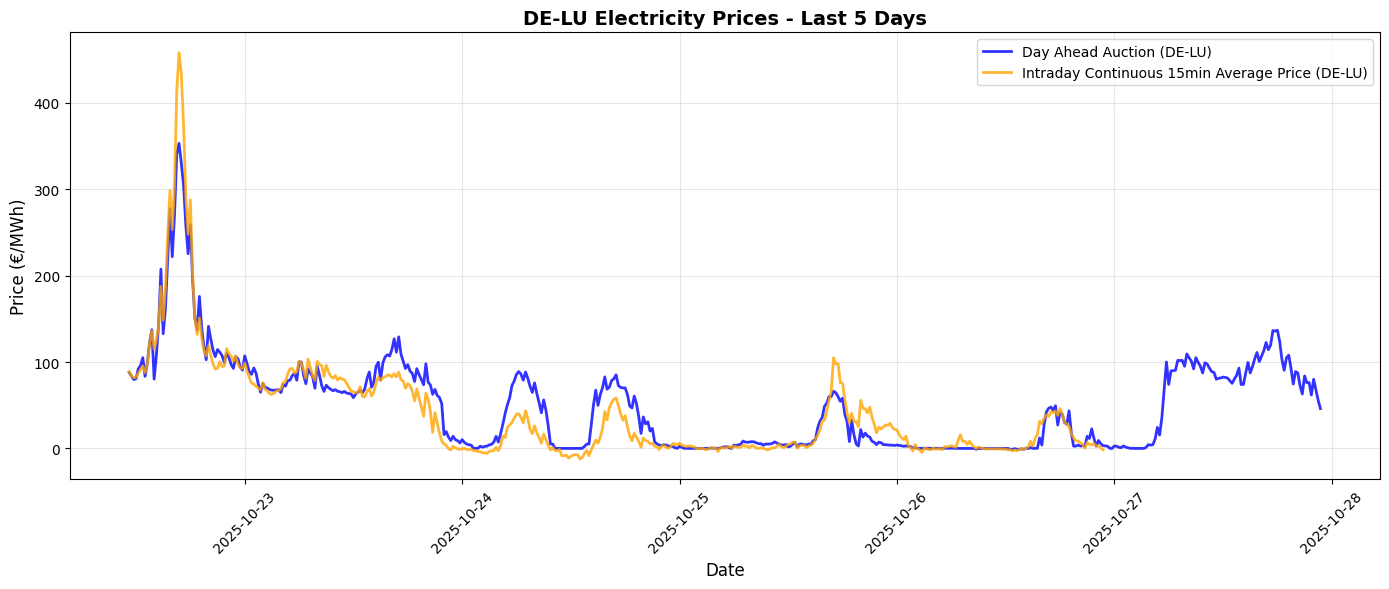

Day Ahead Auction data points (last 5 days): 527
Intraday Average Price data points (last 5 days): 431


In [54]:
# Plot Series 6 (Day Ahead Auction) and Series 8 (Intraday Continuous 15min Average Price) for the last 5 days
timestamps = json_data[0]['xAxisValues']

# Extract data from both series
series6_data = json_data[6]['data']  # Day Ahead Auction
series8_data = json_data[8]['data']  # Intraday Continuous 15 minutes Average Price

# Create DataFrames
df_series6 = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps, unit='ms'),
    'price': series6_data
}).set_index('timestamp').dropna()

df_series8 = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps, unit='ms'),
    'price': series8_data
}).set_index('timestamp').dropna()

# Filter for last 5 days
cutoff_date = datetime.now() - timedelta(days=5)
df_series6_recent = df_series6[df_series6.index >= cutoff_date]
df_series8_recent = df_series8[df_series8.index >= cutoff_date]

# Create plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_series6_recent.index, df_series6_recent['price'], 
        label='Day Ahead Auction (DE-LU)', linewidth=2, alpha=0.8, color='blue')
ax.plot(df_series8_recent.index, df_series8_recent['price'], 
        label='Intraday Continuous 15min Average Price (DE-LU)', linewidth=2, alpha=0.8, color='orange')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (€/MWh)', fontsize=12)
ax.set_title('DE-LU Electricity Prices - Last 5 Days', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Day Ahead Auction data points (last 5 days): {len(df_series6_recent)}")
print(f"Intraday Average Price data points (last 5 days): {len(df_series8_recent)}")


In [49]:
# Find the series with xAxisValues (timestamps) - it's in Series 0
timestamps = json_data[0]['xAxisValues']  # xAxisValues is in Series 0 (shared across all series)

# Extract the Day Ahead Auction (DE-LU) time series from Series 6
price_series = json_data[6]  # Series 6 is "Day Ahead Auction (DE-LU)"
prices = price_series['data']

print(f"Timestamps length: {len(timestamps)}")
print(f"Prices length: {len(prices)}")

# Create DataFrame - timestamps are in MILLISECONDS (not seconds)
json_df = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps, unit='ms'),  # Use 'ms' for milliseconds
    'price': prices
})

# Set timestamp as index and drop NaN values
json_df.set_index('timestamp', inplace=True)
json_df.dropna(inplace=True)

print(f"\nJSON DataFrame shape: {json_df.shape}")
print(f"Date range: {json_df.index.min()} to {json_df.index.max()}")
print(f"\nFirst few rows:")
print(json_df.head())
print(f"\nLast few rows:")
print(json_df.tail())


Timestamps length: 28896
Prices length: 28896

JSON DataFrame shape: (2596, 1)
Date range: 2025-09-30 22:00:00 to 2025-10-27 22:45:00

First few rows:
                      price
timestamp                  
2025-09-30 22:00:00  102.60
2025-09-30 22:15:00   92.24
2025-09-30 22:30:00   86.03
2025-09-30 22:45:00   85.39
2025-09-30 23:00:00   89.99

Last few rows:
                     price
timestamp                 
2025-10-27 21:45:00  61.75
2025-10-27 22:00:00  80.00
2025-10-27 22:15:00  68.02
2025-10-27 22:30:00  55.61
2025-10-27 22:45:00  46.07


In [50]:
# Fetch data from Energy Charts API starting from 2025-01-10
start_date = '2025-01-10'
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

def fetch_energy_charts_price(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """Fetch hourly price data from Energy Charts API."""
    base_url = "https://api.energy-charts.info"
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,
        'start': start_date,
        'end': end_date
    }
    
    price_response = requests.get(price_url, params=price_params, timeout=30)
    price_response.raise_for_status()
    price_data = price_response.json()
    
    # Parse price data
    price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
    prices = price_data['price']
    price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
    return price_df

# Fetch from API
api_df = fetch_energy_charts_price(start_date, end_date)
print(f"API DataFrame shape: {api_df.shape}")


API DataFrame shape: (8835, 1)


In [51]:
# Filter JSON data to only include data from 2025-01-10 onwards
json_df_filtered = json_df[json_df.index >= '2025-01-10'].copy()

# Merge the two datasets on timestamp
comparison_df = api_df.join(json_df_filtered, rsuffix='_json', how='inner')

print(f"Merged DataFrame shape: {comparison_df.shape}")
print(f"\nFirst few rows:")
print(comparison_df.head())


Merged DataFrame shape: (2500, 2)

First few rows:
                      price  price_json
2025-09-30 22:00:00  102.60      102.60
2025-09-30 22:15:00   92.24       92.24
2025-09-30 22:30:00   86.03       86.03
2025-09-30 22:45:00   85.39       85.39
2025-09-30 23:00:00   89.99       89.99


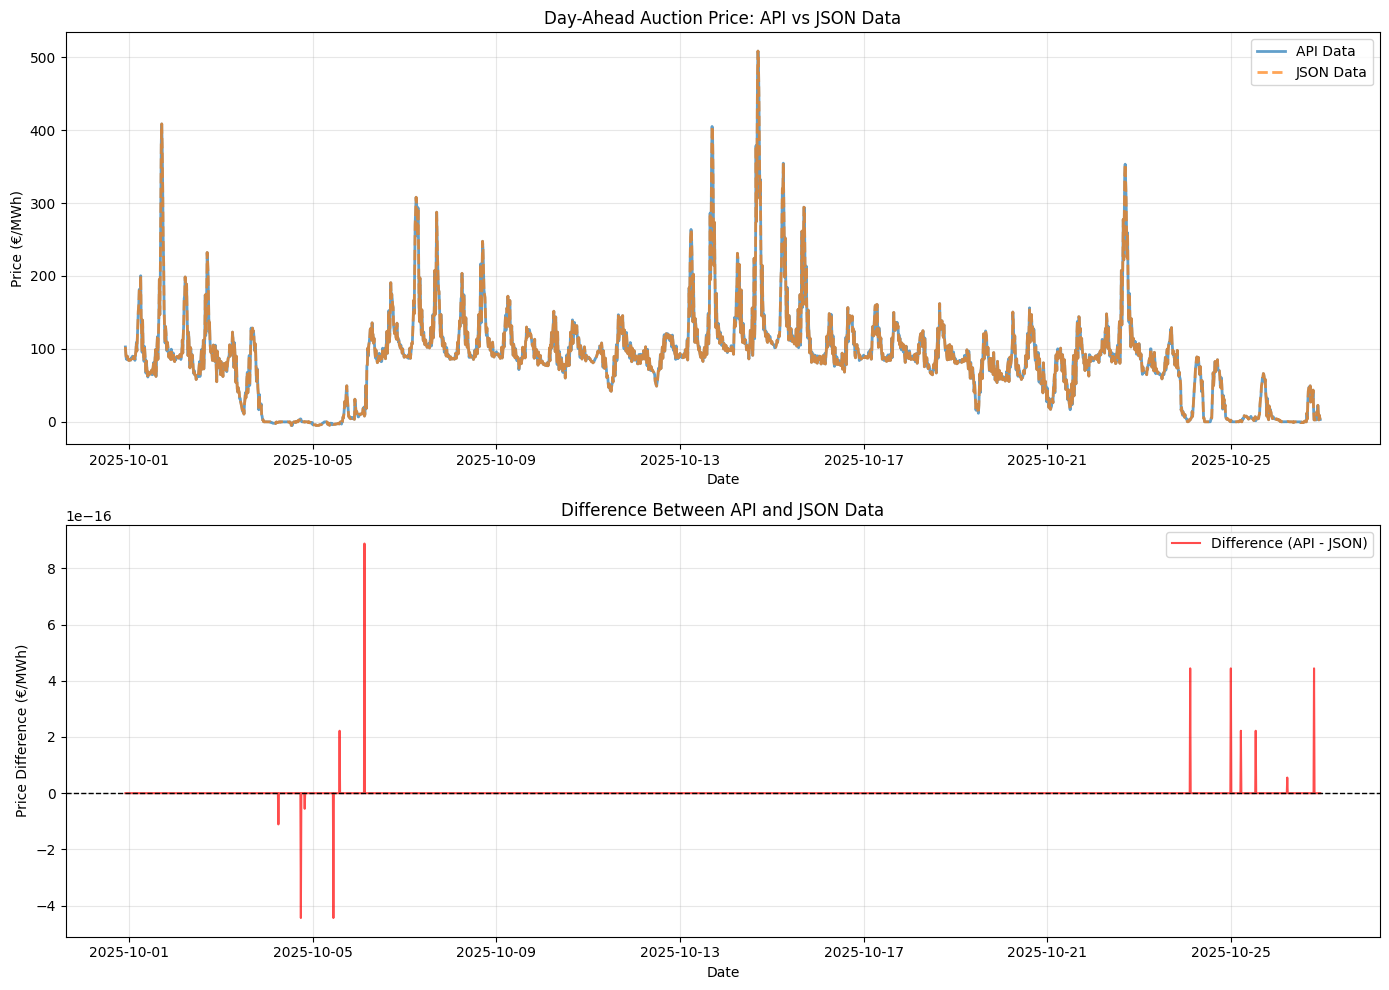

In [52]:
# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Overlay both datasets
axes[0].plot(comparison_df.index, comparison_df['price'], 
             label='API Data', linewidth=2, alpha=0.7)
axes[0].plot(comparison_df.index, comparison_df['price_json'], 
             label='JSON Data', linewidth=2, alpha=0.7, linestyle='--')

axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_title('Day-Ahead Auction Price: API vs JSON Data')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom plot: Difference between the two
difference = comparison_df['price'] - comparison_df['price_json']
axes[1].plot(comparison_df.index, difference, 
             label='Difference (API - JSON)', linewidth=1.5, color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price Difference (€/MWh)')
axes[1].set_title('Difference Between API and JSON Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [53]:
# Calculate statistics
print("="*70)
print("COMPARISON STATISTICS")
print("="*70)

# Drop rows where either value is NaN
valid_comparison = comparison_df.dropna()

if len(valid_comparison) > 0:
    print(f"\nNumber of matching timestamps: {len(valid_comparison)}")
    
    # Calculate correlation
    correlation = valid_comparison['price'].corr(valid_comparison['price_json'])
    print(f"\nCorrelation coefficient: {correlation:.6f}")
    
    # Calculate mean difference
    mean_diff = (valid_comparison['price'] - valid_comparison['price_json']).mean()
    std_diff = (valid_comparison['price'] - valid_comparison['price_json']).std()
    max_diff = (valid_comparison['price'] - valid_comparison['price_json']).abs().max()
    
    print(f"\nDifference Statistics:")
    print(f"  Mean difference: {mean_diff:.4f} €/MWh")
    print(f"  Std deviation of difference: {std_diff:.4f} €/MWh")
    print(f"  Max absolute difference: {max_diff:.4f} €/MWh")
    
    # Calculate number of exact matches and near matches
    exact_matches = (valid_comparison['price'] == valid_comparison['price_json']).sum()
    near_matches_1 = (np.abs(valid_comparison['price'] - valid_comparison['price_json']) <= 1.0).sum()
    near_matches_5 = (np.abs(valid_comparison['price'] - valid_comparison['price_json']) <= 5.0).sum()
    
    print(f"\nMatch Statistics:")
    print(f"  Exact matches: {exact_matches} ({exact_matches/len(valid_comparison)*100:.2f}%)")
    print(f"  Within ±1 €/MWh: {near_matches_1} ({near_matches_1/len(valid_comparison)*100:.2f}%)")
    print(f"  Within ±5 €/MWh: {near_matches_5} ({near_matches_5/len(valid_comparison)*100:.2f}%)")
    
    # Sample values for inspection
    print(f"\nSample values (first 10 rows):")
    print(valid_comparison[['price', 'price_json']].head(10))
else:
    print("\nNo matching timestamps found between API and JSON data")
    print(f"API date range: {api_df.index.min()} to {api_df.index.max()}")
    print(f"JSON date range: {json_df_filtered.index.min()} to {json_df_filtered.index.max()}")

print("="*70)


COMPARISON STATISTICS

Number of matching timestamps: 2500

Correlation coefficient: 1.000000

Difference Statistics:
  Mean difference: 0.0000 €/MWh
  Std deviation of difference: 0.0000 €/MWh
  Max absolute difference: 0.0000 €/MWh

Match Statistics:
  Exact matches: 2488 (99.52%)
  Within ±1 €/MWh: 2500 (100.00%)
  Within ±5 €/MWh: 2500 (100.00%)

Sample values (first 10 rows):
                      price  price_json
2025-09-30 22:00:00  102.60      102.60
2025-09-30 22:15:00   92.24       92.24
2025-09-30 22:30:00   86.03       86.03
2025-09-30 22:45:00   85.39       85.39
2025-09-30 23:00:00   89.99       89.99
2025-09-30 23:15:00   86.03       86.03
2025-09-30 23:30:00   85.03       85.03
2025-09-30 23:45:00   84.09       84.09
2025-10-01 00:00:00   85.41       85.41
2025-10-01 00:15:00   85.00       85.00
